The idea behind this visualization is to understand how the data augmentations affect the image.

/home/pierre/.local/lib/python3.10/site-packages/pydantic/main.py:426: UserWarning: Pydantic serializer warnings:
  Expected `dict[str, any]` but got `UniformParams` with value `UniformParams(noise_type=...6, 0.0784313725490196)])` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


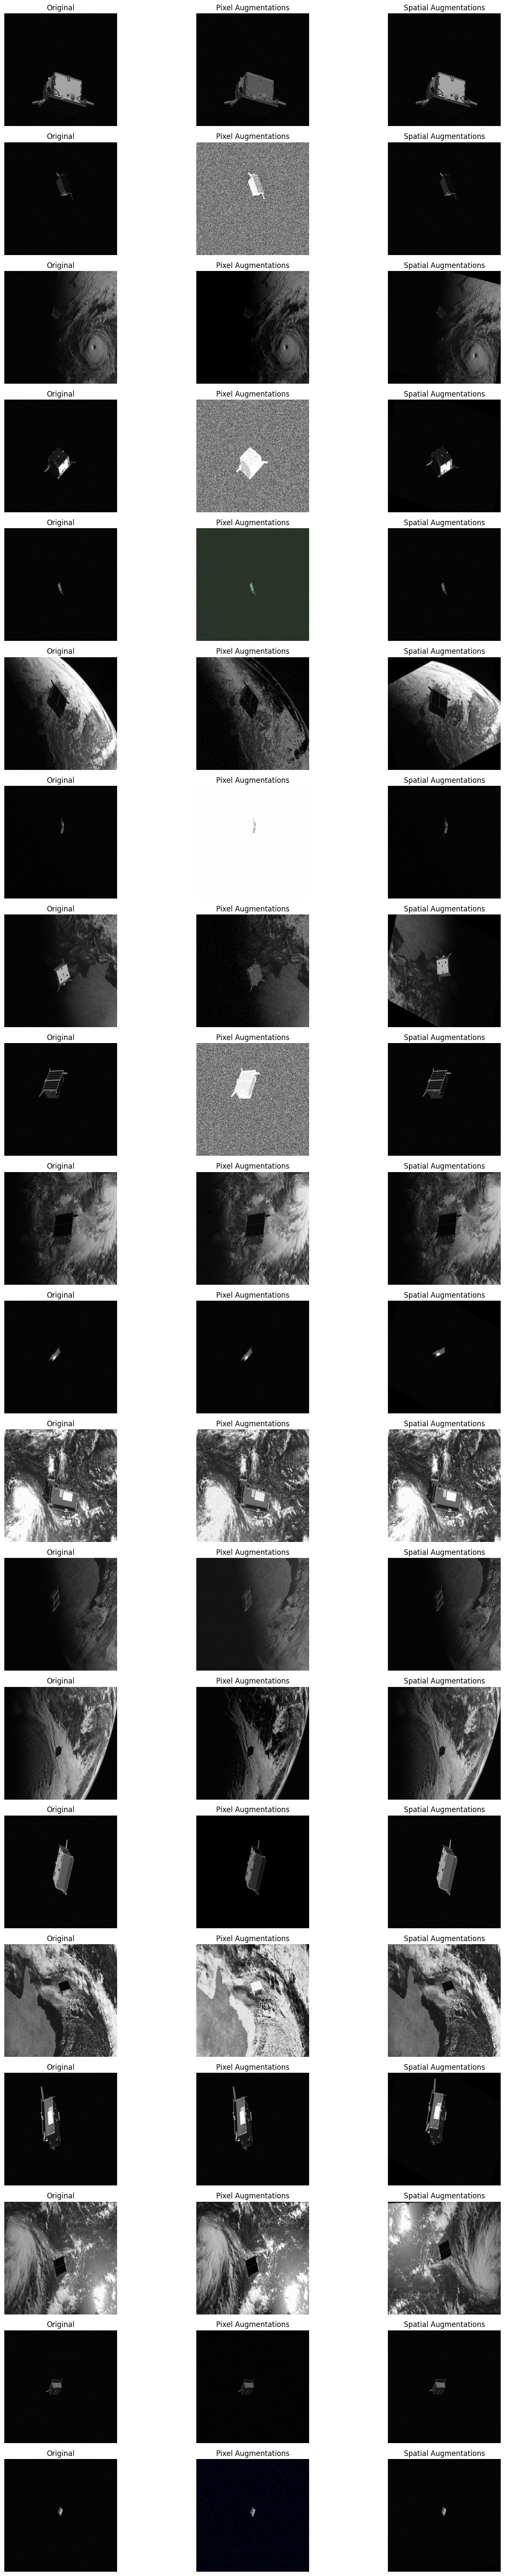

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.datasets import SPEEDDataset
from types import SimpleNamespace
import os


def denormalize_image(tensor):
    """Denormalize image tensor to numpy array"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor.numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


def ensure_dir(directory):
    """Create directory if it doesn't exist"""
    if not os.path.exists(directory):
        os.makedirs(directory)


def visualize_augmentations(dataset_path, num_samples=5):
    # Create output directories
    ensure_dir("images/original")
    ensure_dir("images/pixel")
    ensure_dir("images/spatial")

    # Args for original images (no augmentations)
    args_original = SimpleNamespace(
        no_pixel_augmentation=True,
        no_spatial_augmentation=True,
        no_translation_compensation=False,
        no_rotation_compensation=False,
    )

    # Args for pixel augmentations only
    args_pixel = SimpleNamespace(
        no_pixel_augmentation=False,
        no_spatial_augmentation=True,
        no_translation_compensation=False,
        no_rotation_compensation=False,
    )

    # Args for spatial augmentations only
    args_spatial = SimpleNamespace(
        no_pixel_augmentation=True,
        no_spatial_augmentation=False,
        no_translation_compensation=False,
        no_rotation_compensation=False,
    )

    # Create datasets
    dataset_original = SPEEDDataset(
        dataset_path, split="train", args=args_original, img_size=(512, 512)
    )
    dataset_pixel = SPEEDDataset(dataset_path, split="train", args=args_pixel, img_size=(512, 512))
    dataset_spatial = SPEEDDataset(
        dataset_path, split="train", args=args_spatial, img_size=(512, 512)
    )

    # Create figure
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 3 * num_samples))

    for i in range(num_samples):
        # Get the same image for all three versions
        idx = np.random.randint(len(dataset_original))

        # Get original filename
        filename = dataset_original.data[idx]["filename"]
        basename = os.path.splitext(filename)[0]

        # Get all three versions of the image
        img_orig, _, _, _ = dataset_original[idx]
        img_pixel, _, _, _ = dataset_pixel[idx]
        img_spatial, _, _, _ = dataset_spatial[idx]

        # Denormalize images
        img_orig = denormalize_image(img_orig)
        img_pixel = denormalize_image(img_pixel)
        img_spatial = denormalize_image(img_spatial)

        # Save images
        plt.imsave(f"images/original/{basename}.png", img_orig)
        plt.imsave(f"images/pixel/{basename}.png", img_pixel)
        plt.imsave(f"images/spatial/{basename}.png", img_spatial)

        # Plot images
        axes[i, 0].imshow(img_orig)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img_pixel)
        axes[i, 1].set_title("Pixel Augmentations")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img_spatial)
        axes[i, 2].set_title("Spatial Augmentations")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Might need to change the dataset path
    dataset_path = "../SPEED_FIXED"
    visualize_augmentations(dataset_path, num_samples=20)